In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR='/content/drive/MyDrive/Thesis'
zip_file_path=BASE_DIR+'/balanced_resizeed.zip'
extract_to_directory = BASE_DIR

In [ ]:
import zipfile
import os

def unzip_file(zip_path, extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Specify the path to the zip file and the directory to extract to

# Create the directory if it doesn't exist
os.makedirs(extract_to_directory, exist_ok=True)

# Unzip the file
unzip_file(zip_file_path, extract_to_directory)

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from skimage.io import imread
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

In [ ]:
extract_to_directory='/content/drive/MyDrive/Thesis/balanced_resizeed'

In [ ]:
folder_path = extract_to_directory
dirs = os.listdir(folder_path)

print(dirs)

['Banana_Immature', 'Banana_Mature', 'Banana_Semi-mature', 'Guava_Immature', 'Guava_Mature', 'Guava_Semi-mature', 'Lemon-Immature', 'Lemon_Mature', 'Lemon_Semi-mature', 'Mango_Immature', 'Mango_Mature', 'Mango_Semimature', 'Papaya_Immature', 'Papaya_Mature', 'Papaya_Semi-mature', 'Tomatoo-mature', 'Tomato_Immature', 'Tomato_Semi-mature']


In [ ]:
for i in range(len(dirs)):
    types = set()
    for n in os.listdir(os.path.join(folder_path, dirs[i])):
        types.add(n.split('.')[-1])

    print(dirs[i] + ':', types)


Banana_Immature: {'jpg'}
Banana_Mature: {'jpg'}
Banana_Semi-mature: {'jpg'}
Guava_Immature: {'jpg'}
Guava_Mature: {'jpg'}
Guava_Semi-mature: {'jpg'}
Lemon-Immature: {'jpg'}
Lemon_Mature: {'jpg'}
Lemon_Semi-mature: {'jpg'}
Mango_Immature: {'jpg'}
Mango_Mature: {'jpg'}
Mango_Semimature: {'jpg'}
Papaya_Immature: {'jpg'}
Papaya_Mature: {'jpg'}
Papaya_Semi-mature: {'jpg'}
Tomatoo-mature: {'jpg'}
Tomato_Immature: {'jpg'}
Tomato_Semi-mature: {'jpg'}


In [ ]:
for i in range(len(dirs)):
    class_folder = os.path.join(folder_path, dirs[i])
    files_path = os.listdir(class_folder)
    size = set()

    #fp = files_path
    for fp in files_path:
        img = imread(os.path.join(class_folder, fp))
        size.add(img.shape)

    print('(Height, Width, Channels)')
    print(70*'-')
    print(dirs[i] + ':', size)

(Height, Width, Channels)
----------------------------------------------------------------------
Banana_Immature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Banana_Mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Banana_Semi-mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Immature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Semi-mature: {(320, 320, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Lemon-Immature: {(320, 320, 3)}
(Height, Width, Channels)
------------------------------------------------------------------

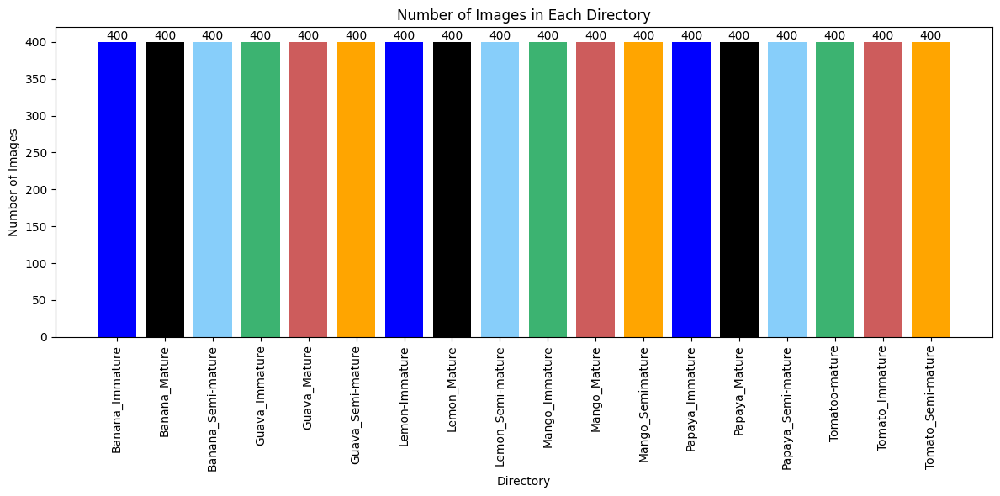

In [ ]:

image_counts = []
for directory in dirs:
    sub_dir = os.path.join(folder_path, directory)
    if os.path.isdir(sub_dir):
        file_count = len(os.listdir(sub_dir))
        image_counts.append(file_count)


plt.figure(figsize=(12,6))
for i in range(len(dirs)):
    plt.text(i, image_counts[i], str(image_counts[i]), ha='center', va='bottom')


colors = ['blue','black','lightskyblue', 'mediumseagreen', 'indianred', 'orange']


plt.bar(dirs, image_counts, color=colors)
plt.xlabel('Directory')
plt.xticks(rotation=90)
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Directory')
plt.tight_layout()
plt.show()

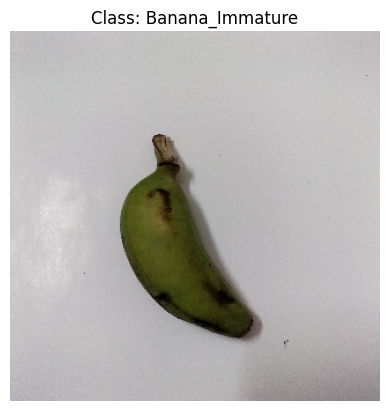

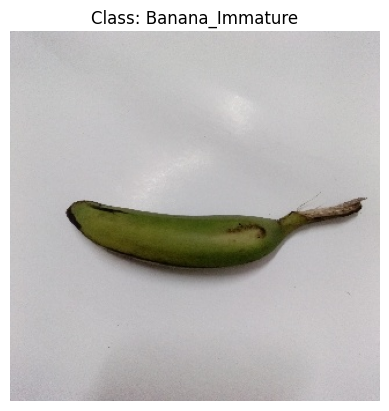

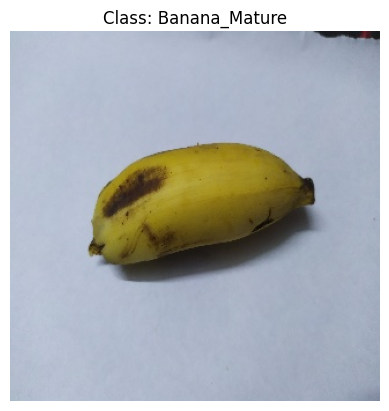

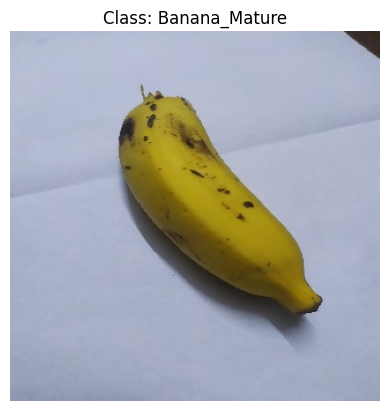

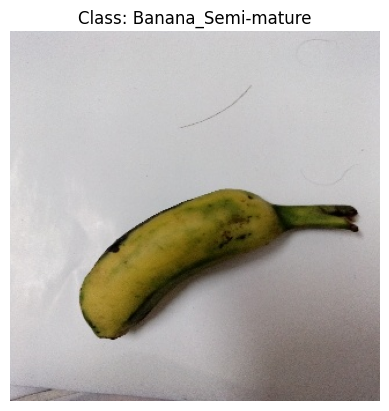

...

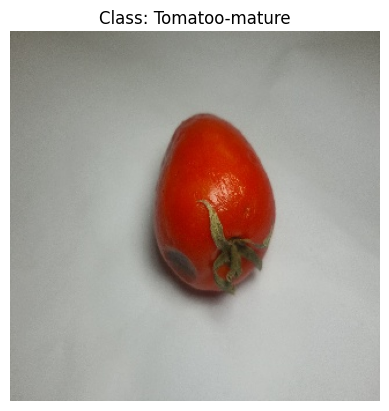

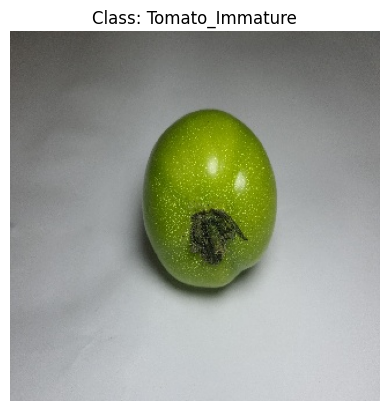

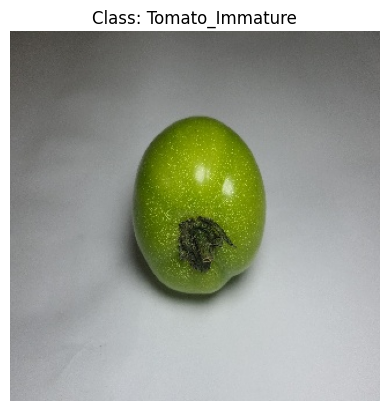

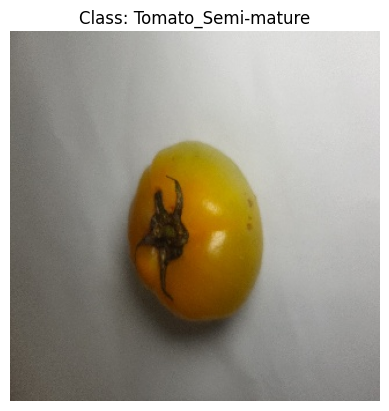

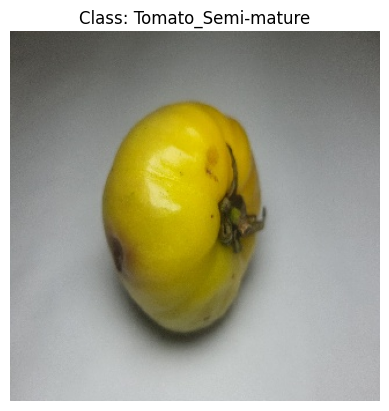

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to the parent directory containing class folders
parent_directory = folder_path

# Get a list of class folders (assuming folder names correspond to class names)
class_folders = os.listdir(parent_directory)

# Define the number of images to print from each class
num_images_to_print = 2

# Iterate through each class folder
for class_folder in class_folders:
    class_path = os.path.join(parent_directory, class_folder)

    # Get a list of image files in the class folder
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

    # Check if there are at least two images in the class folder
    if len(image_files) >= num_images_to_print:
        random_images = random.sample(image_files, num_images_to_print)
    else:
        # If there are fewer than two images, use all available images
        random_images = image_files

    # Print the images and their labels
    for image_file in random_images:
        image_path = os.path.join(class_path, image_file)
        image = mpimg.imread(image_path)

        plt.figure()
        plt.imshow(image)
        plt.title(f'Class: {class_folder}')
        plt.axis('off')
        plt.show()

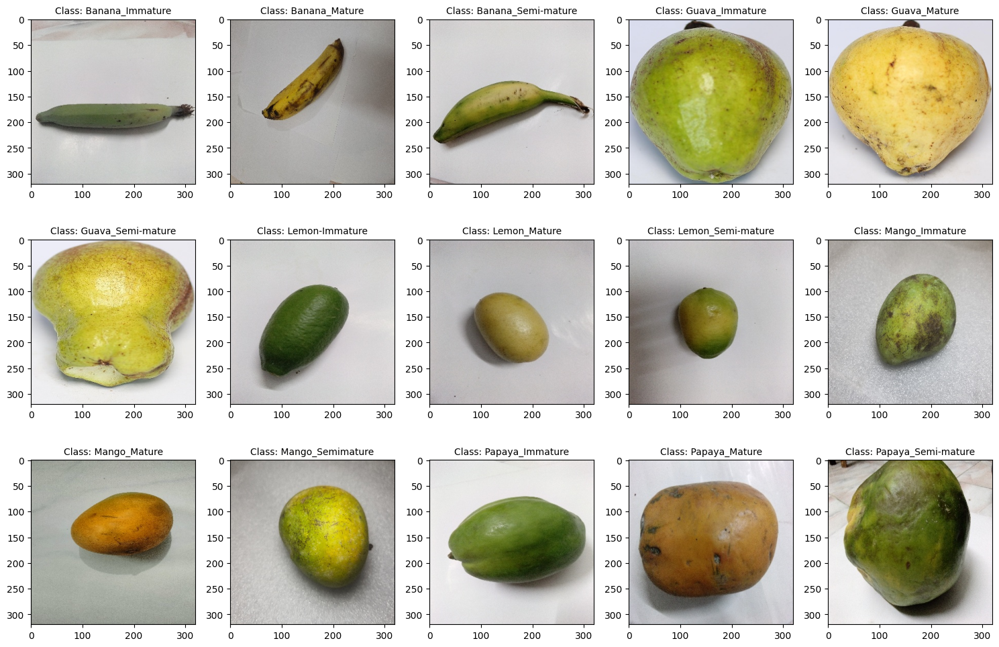

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to the parent directory containing class folders
parent_directory = folder_path

# Get a list of class folders (assuming folder names correspond to class names)
class_folders = os.listdir(parent_directory)

# Define the number of images to print from each class (in this case, 1)
num_images_to_print = 1

# Calculate the number of rows and columns for the subplots
num_rows = 3
num_cols = 5

# Calculate the total number of subplots
total_subplots = num_rows * num_cols

# Create a single figure with subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Iterate through each class folder
for idx, class_folder in enumerate(class_folders):
    if idx >= total_subplots:
        break  # Exit the loop if there are more classes than available subplots

    class_path = os.path.join(parent_directory, class_folder)

    # Get a list of image files in the class folder
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

    # Check if there is at least one image in the class folder
    if len(image_files) > 0:
        # Randomly select one image to print
        random_image = random.choice(image_files)

        # Calculate the row and column index for the subplot
        row = idx // num_cols
        col = idx % num_cols

        # Load and plot the selected image
        image_path = os.path.join(class_path, random_image)
        image = mpimg.imread(image_path)

        # Plot the image in the appropriate subplot
        axs[row, col].imshow(image)
        axs[row, col].set_title(f'Class: {class_folder}', fontsize=10)  # Adjust text size
        axs[row, col].axis('on')

# Remove any remaining empty subplots
for idx in range(len(class_folders), total_subplots):
    row = idx // num_cols
    col = idx % num_cols
    fig.delaxes(axs[row, col])

# Adjust spacing between subplots
plt.tight_layout()

# Show the single figure containing all subplots
plt.show()

Train Test **Spilt**

In [ ]:
base_dest_dir = BASE_DIR+'/split'  # Base directory in Colab environment

In [ ]:
train_ratio=float(0.8)
test_ratio=float(0.1)


In [ ]:
import os
import shutil
import random

# Set paths for source and destination directories
source_dir = folder_path

# Create base destination directory
os.makedirs(base_dest_dir, exist_ok=True)

# Get a list of all subdirectories in the source directory
subdirectories = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

# Loop through each subdirectory and split images
for subdir in subdirectories:
    subdir_path = os.path.join(source_dir, subdir)

    # Create train, test, and validation subdirectories
    train_dir = os.path.join(base_dest_dir, 'train', subdir)
    test_dir = os.path.join(base_dest_dir, 'test', subdir)
    validation_dir = os.path.join(base_dest_dir, 'validation', subdir)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    os.makedirs(validation_dir, exist_ok=True)

    # List all image files in the subdirectory
    image_files = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Shuffle the image files
    random.shuffle(image_files)

    # Calculate the number of images for each split
    total_images = len(image_files)
    train_count = int(train_ratio * total_images)
    test_count = int(test_ratio * total_images)
    validation_count = total_images - train_count - test_count

    # Split the image files into train, test, and validation sets
    train_images = image_files[:train_count]
    test_images = image_files[train_count:train_count + test_count]
    validation_images = image_files[train_count + test_count:]

    # Function to copy images from source to destination
    def copy_images(image_list, source, dest):
        for image in image_list:
            src_path = os.path.join(source, subdir, image)
            dest_path = os.path.join(dest, image)
            shutil.copy(src_path, dest_path)

    # Copy images to respective subdirectories
    copy_images(train_images, source_dir, train_dir)
    copy_images(test_images, source_dir, test_dir)
    copy_images(validation_images, source_dir, validation_dir)

print(f"Spliting finished! with train ratio = {train_ratio} and test ratio = {test_ratio}")

Spliting finished! with train ratio = 0.8 and test ratio = 0.1


**Print Images of train folder after spliting**

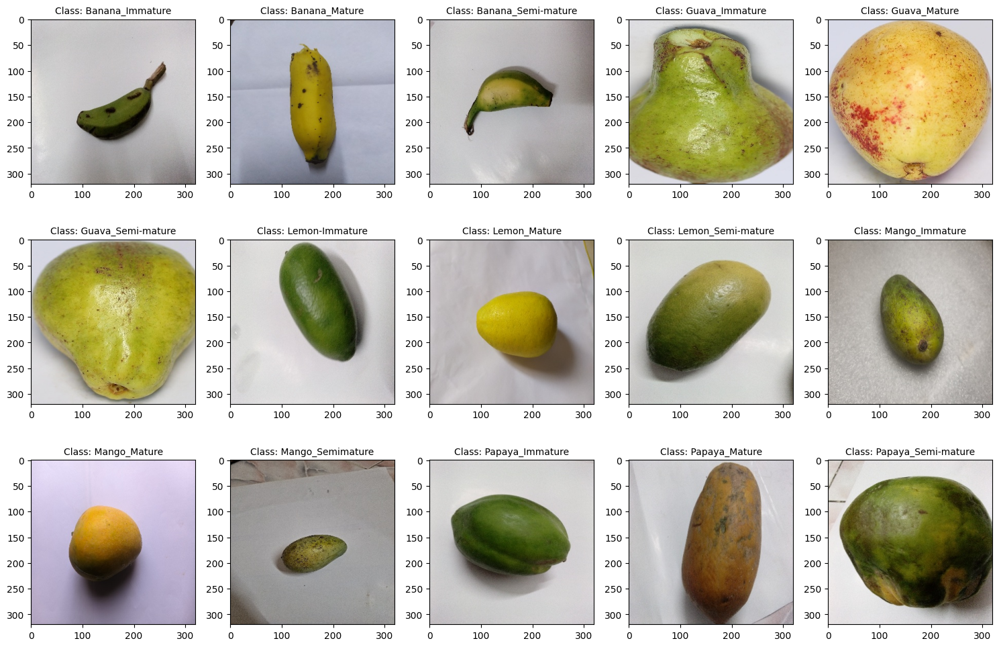

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to the parent directory containing class folders
parent_directory = base_dest_dir+'/train'

# Get a list of class folders (assuming folder names correspond to class names)
class_folders = os.listdir(parent_directory)

# Define the number of images to print from each class (in this case, 1)
num_images_to_print = 1

# Calculate the number of rows and columns for the subplots
num_rows = 3
num_cols = 5

# Calculate the total number of subplots
total_subplots = num_rows * num_cols

# Create a single figure with subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Iterate through each class folder
for idx, class_folder in enumerate(class_folders):
    if idx >= total_subplots:
        break  # Exit the loop if there are more classes than available subplots

    class_path = os.path.join(parent_directory, class_folder)

    # Get a list of image files in the class folder
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

    # Check if there is at least one image in the class folder
    if len(image_files) > 0:
        # Randomly select one image to print
        random_image = random.choice(image_files)

        # Calculate the row and column index for the subplot
        row = idx // num_cols
        col = idx % num_cols

        # Load and plot the selected image
        image_path = os.path.join(class_path, random_image)
        image = mpimg.imread(image_path)

        # Plot the image in the appropriate subplot
        axs[row, col].imshow(image)
        axs[row, col].set_title(f'Class: {class_folder}', fontsize=10)  # Adjust text size
        axs[row, col].axis('on')

# Remove any remaining empty subplots
for idx in range(len(class_folders), total_subplots):
    row = idx // num_cols
    col = idx % num_cols
    fig.delaxes(axs[row, col])

# Adjust spacing between subplots
plt.tight_layout()

# Show the single figure containing all subplots
plt.show()

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
# warnings.filterwarnings("ignore", category=ConvergenceWarning)
# warnings.simplefilter(action='ignore', category=FutureWarning)
# warnings.simplefilter(action='ignore', category=UserWarning)

import itertools
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.metrics import classification_report, f1_score , confusion_matrix,accuracy_score



# Tensorflow Libraries
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout , BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers,models,Model
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


print(tf.__version__)

2.14.0


In [ ]:
train_path=base_dest_dir+'/train'
test_path=base_dest_dir+'/test'
val_path=base_dest_dir+'/validation'

In [ ]:
dataset = {
             "train_data" : train_path,
             "valid_data" : val_path,
             "test_data" : test_path
          }

all_data = []
for path in dataset.values():
    data = {"imgpath": [] , "labels": [] }
    category = os.listdir(path)

    for folder in category:
        folderpath = os.path.join(path , folder)
        filelist = os.listdir(folderpath)
        for file in filelist:
            fpath = os.path.join(folderpath, file)
            data["imgpath"].append(fpath)
            data["labels"].append(folder)


    all_data.append(data.copy())
    data.clear()



train_df = pd.DataFrame(all_data[0] , index=range(len(all_data[0]['imgpath'])))
valid_df = pd.DataFrame(all_data[1] , index=range(len(all_data[1]['imgpath'])))
test_df = pd.DataFrame(all_data[2] , index=range(len(all_data[2]['imgpath'])))


# #Convert labels to numbers
lb = LabelEncoder()
train_df['encoded_labels'] = lb.fit_transform(train_df['labels'])
valid_df['encoded_labels'] = lb.fit_transform(valid_df['labels'])
test_df['encoded_labels'] = lb.fit_transform(test_df['labels'])

In [ ]:
train_df.sample(n=15, random_state=1)

,imgpath,labels,encoded_labels
473,/content/drive/MyDrive/Thesis/split/train/Bana...,Banana_Mature,1
5519,/content/drive/MyDrive/Thesis/split/train/Toma...,Tomato_Semi-mature,16
1807,/content/drive/MyDrive/Thesis/split/train/Guav...,Guava_Semi-mature,5
4367,/content/drive/MyDrive/Thesis/split/train/Papa...,Papaya_Mature,13
3451,/content/drive/MyDrive/Thesis/split/train/Mang...,Mango_Mature,10
3945,/content/drive/MyDrive/Thesis/split/train/Papa...,Papaya_Immature,12
1564,/content/drive/MyDrive/Thesis/split/train/Guav...,Guava_Mature,4
1764,/content/drive/MyDrive/Thesis/split/train/Guav...,Guava_Semi-mature,5
3093,/content/drive/MyDrive/Thesis/split/train/Mang...,Mango_Immature,9
233,/content/drive/MyDrive/Thesis/split/train/Bana...,Banana_Immature,0


In [ ]:
print("----------Train-------------")
print(train_df[["imgpath", "labels"]].tail(5))
print(train_df.shape)
print("--------Validation----------")
print(valid_df[["imgpath", "labels"]].head(5))
print(valid_df.shape)
print("----------Test--------------")
print(test_df[["imgpath", "labels"]].head(5))
print(test_df.shape)

----------Train-------------
                                                imgpath              labels
5755  /content/drive/MyDrive/Thesis/split/train/Toma...  Tomato_Semi-mature
5756  /content/drive/MyDrive/Thesis/split/train/Toma...  Tomato_Semi-mature
5757  /content/drive/MyDrive/Thesis/split/train/Toma...  Tomato_Semi-mature
5758  /content/drive/MyDrive/Thesis/split/train/Toma...  Tomato_Semi-mature
5759  /content/drive/MyDrive/Thesis/split/train/Toma...  Tomato_Semi-mature
(5760, 3)
--------Validation----------
                                             imgpath           labels
0  /content/drive/MyDrive/Thesis/split/validation...  Banana_Immature
1  /content/drive/MyDrive/Thesis/split/validation...  Banana_Immature
2  /content/drive/MyDrive/Thesis/split/validation...  Banana_Immature
3  /content/drive/MyDrive/Thesis/split/validation...  Banana_Immature
4  /content/drive/MyDrive/Thesis/split/validation...  Banana_Immature
(720, 3)
----------Test--------------
                  

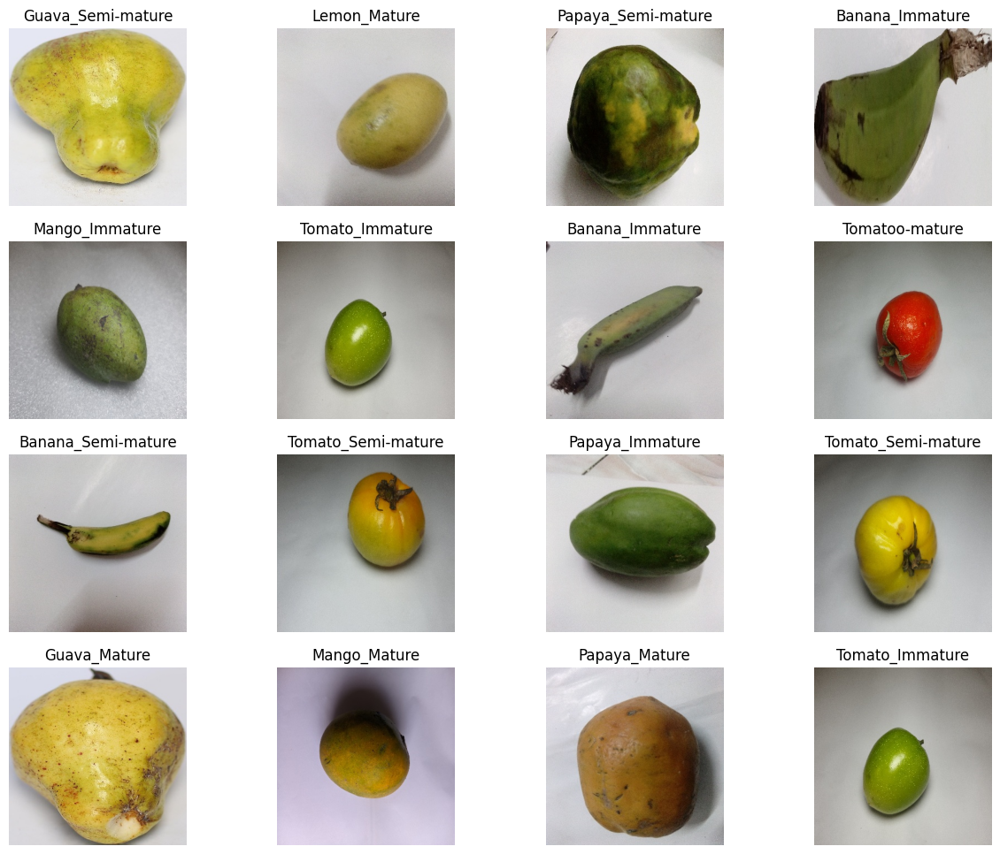

In [ ]:
plt.figure(figsize=(15,12))
for i, row in valid_df.sample(n=16).reset_index().iterrows():
    plt.subplot(4,4,i+1)
    image_path = row['imgpath']
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(row["labels"])
    plt.axis('off')
plt.show()

In [ ]:
%%time

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)


generator = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet.preprocess_input,
    # there could be image augmentation here
)

# Split the data into three categories.
train_images = generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='imgpath',
    y_col='labels',
    target_size=IMAGE_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

val_images = generator.flow_from_dataframe(
    dataframe=valid_df,
    x_col='imgpath',
    y_col='labels',
    target_size=IMAGE_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_images = generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='imgpath',
    y_col='labels',
    target_size=IMAGE_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5760 validated image filenames belonging to 18 classes.
Found 720 validated image filenames belonging to 18 classes.
Found 720 validated image filenames belonging to 18 classes.
CPU times: user 193 ms, sys: 156 ms, total: 349 ms
Wall time: 2.68 s


In [ ]:
# Load the pretained model
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # we don`t need a pre-trained top layer (output layer)
    weights='imagenet',
    pooling='max'
)
# Freezing the layers of a pretrained neural network
for i, layer in enumerate(pretrained_model.layers):
    pretrained_model.layers[i].trainable = False

In [ ]:

pretrained_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_5[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[

**TO add augmentation layers and bottom layers**

In [ ]:
num_classes = len(set(train_images.classes))
print(num_classes)


# # Data Augmentation LAYERS

# augment = tf.keras.Sequential([
#   layers.experimental.preprocessing.RandomFlip("horizontal"),
#   layers.experimental.preprocessing.RandomRotation(0.15),
#   layers.experimental.preprocessing.RandomZoom(0.12),
#   layers.experimental.preprocessing.RandomContrast(0.12),
# ], name='AugmentationLayer')



# inputs = layers.Input(shape = (224,224,3), name='inputLayer')
# x = augment(inputs)
# pretrain_out = pretrained_model(x, training = False)
# x = layers.Dense(1024)(pretrain_out)
# x = layers.Activation(activation="relu")(x)
# x = BatchNormalization()(x)
# x = layers.Dropout(0.45)(x)
# x = layers.Dense(512)(x)
# x = layers.Activation(activation="relu")(x)
# x = BatchNormalization()(x)
# x = layers.Dropout(0.3)(x)
x = layers.Dense(num_classes)(pretrained_model.output)
outputs = layers.Activation(activation="softmax", dtype=tf.float32, name='activationLayer')(x) # mixed_precision need separated Dense and Activation layers
model = Model(inputs=pretrained_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

18
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_5[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']   



In [ ]:
plot_model(model = model, show_shapes = True)

In [ ]:
history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=10,
    callbacks=[
        EarlyStopping(monitor = "val_loss",
                               patience = 3,
                               restore_best_weights = True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, mode='min')
    ]
)
model.save_weights('./checkpoints/my_checkpoint')

Epoch 1/10
180/180 [==============================] - 37s 147ms/step - loss: 1.8761 - accuracy: 0.4991 - val_loss: 0.8093 - val_accuracy: 0.7319 - lr: 5.0000e-04
Epoch 2/10
180/180 [==============================] - 24s 129ms/step - loss: 0.6157 - accuracy: 0.7866 - val_loss: 0.5536 - val_accuracy: 0.8014 - lr: 5.0000e-04
Epoch 3/10
180/180 [==============================] - 24s 130ms/step - loss: 0.3980 - accuracy: 0.8658 - val_loss: 0.3906 - val_accuracy: 0.8681 - lr: 5.0000e-04
Epoch 4/10
180/180 [==============================] - 25s 137ms/step - loss: 0.3018 - accuracy: 0.9031 - val_loss: 0.3232 - val_accuracy: 0.8917 - lr: 5.0000e-04
Epoch 5/10
180/180 [==============================] - 22s 122ms/step - loss: 0.2358 - accuracy: 0.9219 - val_loss: 0.2869 - val_accuracy: 0.8972 - lr: 5.0000e-04
Epoch 6/10
180/180 [==============================] - 23s 129ms/step - loss: 0.2025 - accuracy: 0.9354 - val_loss: 0.2388 - val_accuracy: 0.9153 - lr: 5.0000e-04
Epoch 7/10
180/180 [========

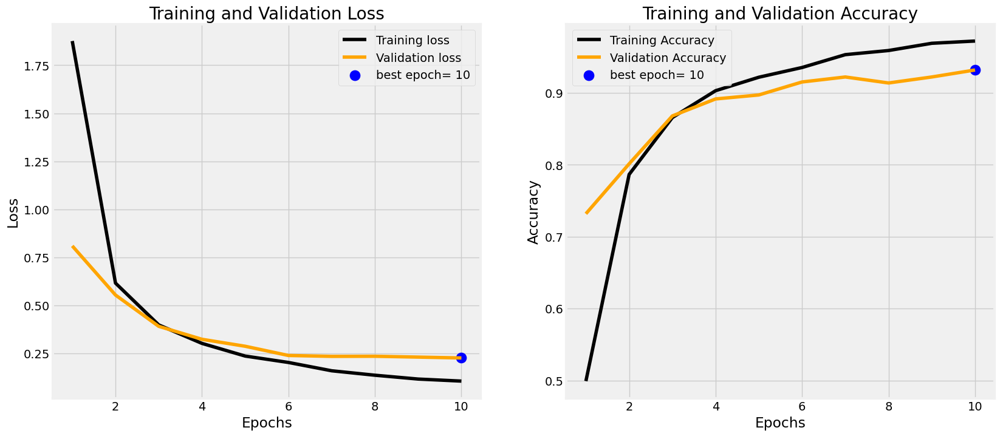

In [ ]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'black', label= 'Training loss')
plt.plot(Epochs, val_loss, 'orange', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'black', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'orange', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
results = model.evaluate(test_images, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.22493
Test Accuracy: 91.11%


F1,Precision,Recall
bold text

In [ ]:
y_true = test_images.classes
y_pred = np.argmax(model.predict(test_images), axis = 1)
f1 = f1_score(y_true, y_pred, average='macro')
print("F1 Score:", f1)
print(classification_report(y_true, y_pred, target_names=test_images.class_indices.keys()))

23/23 [==============================] - 4s 120ms/step
F1 Score: 0.9110577085342657
                    precision    recall  f1-score   support

   Banana_Immature       0.73      0.88      0.80        40
     Banana_Mature       0.97      0.97      0.97        40
Banana_Semi-mature       0.86      0.75      0.80        40
    Guava_Immature       1.00      0.72      0.84        40
      Guava_Mature       1.00      0.57      0.73        40
 Guava_Semi-mature       0.60      1.00      0.75        40
    Lemon-Immature       0.91      0.97      0.94        40
      Lemon_Mature       0.86      0.93      0.89        40
 Lemon_Semi-mature       0.97      0.72      0.83        40
    Mango_Immature       0.98      1.00      0.99        40
      Mango_Mature       1.00      1.00      1.00        40
  Mango_Semimature       0.97      0.97      0.97        40
   Papaya_Immature       0.97      0.95      0.96        40
     Papaya_Mature       1.00      0.97      0.99        40
Papaya_Semi-mat

Get **Predictions**

In [ ]:
classes = dict(zip(test_images.class_indices.values(), test_images.class_indices.keys()))
Predictions = pd.DataFrame({"Image Index" : list(range(len(test_images.labels))),
                            "Test Labels" : test_images.labels,
                            "Test Classes" : [classes[i] for i in test_images.labels],
                            "Prediction Labels" : y_pred,
                            "Prediction Classes" : [classes[i] for i in y_pred],
                            "Path": test_images.filenames,
                            "Prediction Probability" : [x for x in np.asarray(tf.reduce_max(model.predict(test_images), axis = 1))]
                           })
Predictions.head(46)

23/23 [==============================] - 2s 104ms/step


,Image Index,Test Labels,Test Classes,Prediction Labels,Prediction Classes,Path,Prediction Probability
0,0,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.992637
1,1,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.999710
2,2,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.996754
3,3,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.969025
4,4,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.887487
5,5,0,Banana_Immature,2,Banana_Semi-mature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.557133
6,6,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.941919
7,7,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.992828
8,8,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.978867
9,9,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.928028


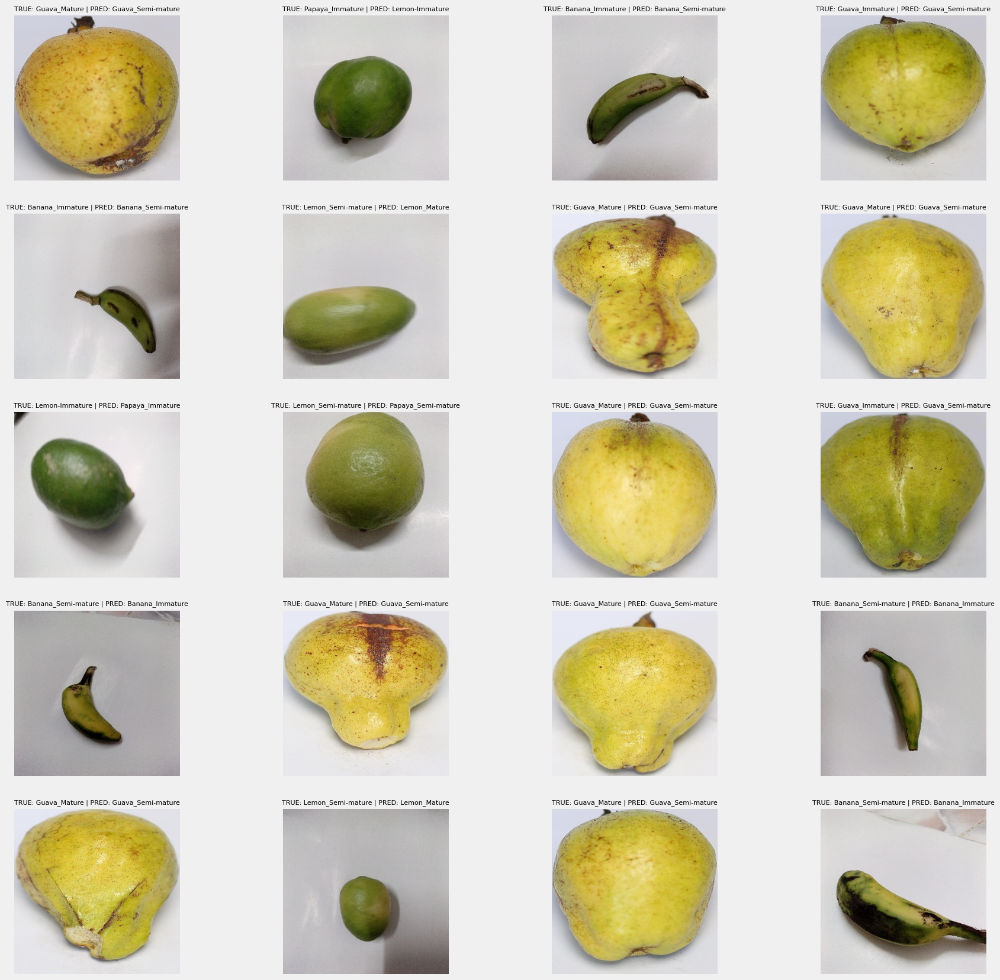

In [ ]:
plt.figure(figsize=(20,20))
for i, row in Predictions[Predictions["Test Labels"] != Predictions["Prediction Labels"]].sort_values("Prediction Probability").tail(20).reset_index().iterrows():
    plt.subplot(5,4,i+1)
    image_path = row['Path']
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(f'TRUE: {row["Test Classes"]} | PRED: {row["Prediction Classes"]}', fontsize=8)
    plt.axis('off')

plt.show()

<ipython-input-48-7fa52ca6893c>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model.predict_generator(test_images)


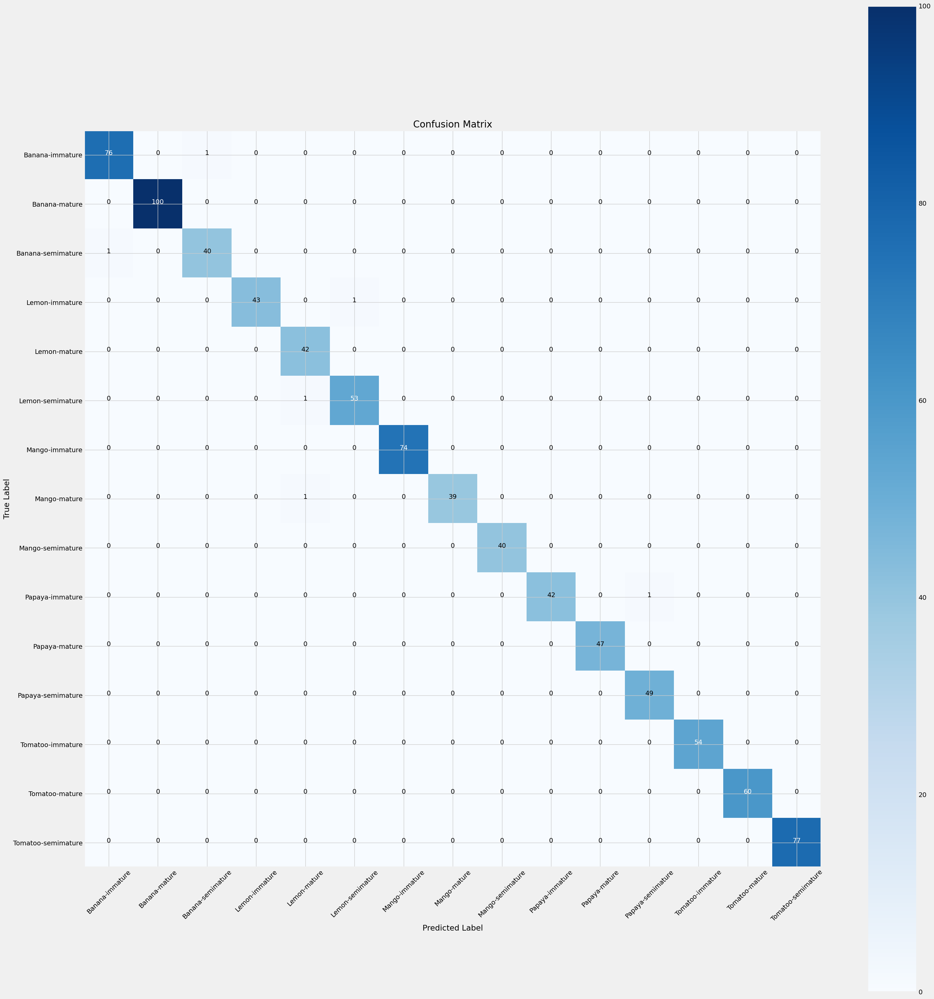

In [ ]:
preds = model.predict_generator(test_images)
y_pred = np.argmax(preds, axis=1)
g_dict = test_images.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_images.classes, y_pred)

plt.figure(figsize= (30, 30))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()


In [ ]:
pretrained_model.trainable = True
for layer in pretrained_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

for l in pretrained_model.layers[:10]:
    print(l.name, l.trainable)

model.compile(
    optimizer=Adam(0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# model.load_weights('./checkpoints/my_checkpoint')
print(model.summary())
history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=20,
    callbacks=[
        EarlyStopping(monitor = "val_loss",
                               patience = 5,
                               restore_best_weights = True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, mode='min')
    ]
)
model.save_weights('./checkpoints/my_checkpoint')

input_5 True
Conv1 True
bn_Conv1 False
Conv1_relu True
expanded_conv_depthwise True
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu True
expanded_conv_project True
expanded_conv_project_BN False
block_1_expand True
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_5[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                         

**Evaluating Models Performance**

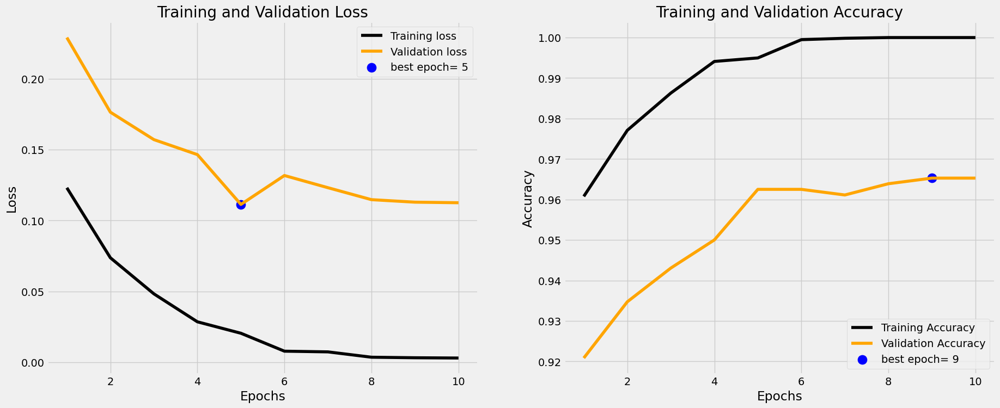

In [ ]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'black', label= 'Training loss')
plt.plot(Epochs, val_loss, 'orange', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'black', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'orange', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()


In [ ]:
y_true = test_images.classes
y_pred = np.argmax(model.predict(test_images), axis = 1)
f1 = accuracy_score(y_true, y_pred)
print("Accuracy:", f1)
print(classification_report(y_true, y_pred, target_names=test_images.class_indices.keys()))

23/23 [==============================] - 4s 124ms/step
Accuracy: 0.9652777777777778
                    precision    recall  f1-score   support

   Banana_Immature       0.92      0.85      0.88        40
     Banana_Mature       1.00      1.00      1.00        40
Banana_Semi-mature       0.86      0.93      0.89        40
    Guava_Immature       0.97      0.97      0.97        40
      Guava_Mature       0.94      0.85      0.89        40
 Guava_Semi-mature       0.84      0.93      0.88        40
    Lemon-Immature       1.00      0.97      0.99        40
      Lemon_Mature       0.95      0.95      0.95        40
 Lemon_Semi-mature       0.97      0.93      0.95        40
    Mango_Immature       1.00      1.00      1.00        40
      Mango_Mature       1.00      1.00      1.00        40
  Mango_Semimature       1.00      1.00      1.00        40
   Papaya_Immature       0.98      1.00      0.99        40
     Papaya_Mature       1.00      1.00      1.00        40
Papaya_Semi-mat

<ipython-input-53-7fa52ca6893c>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model.predict_generator(test_images)


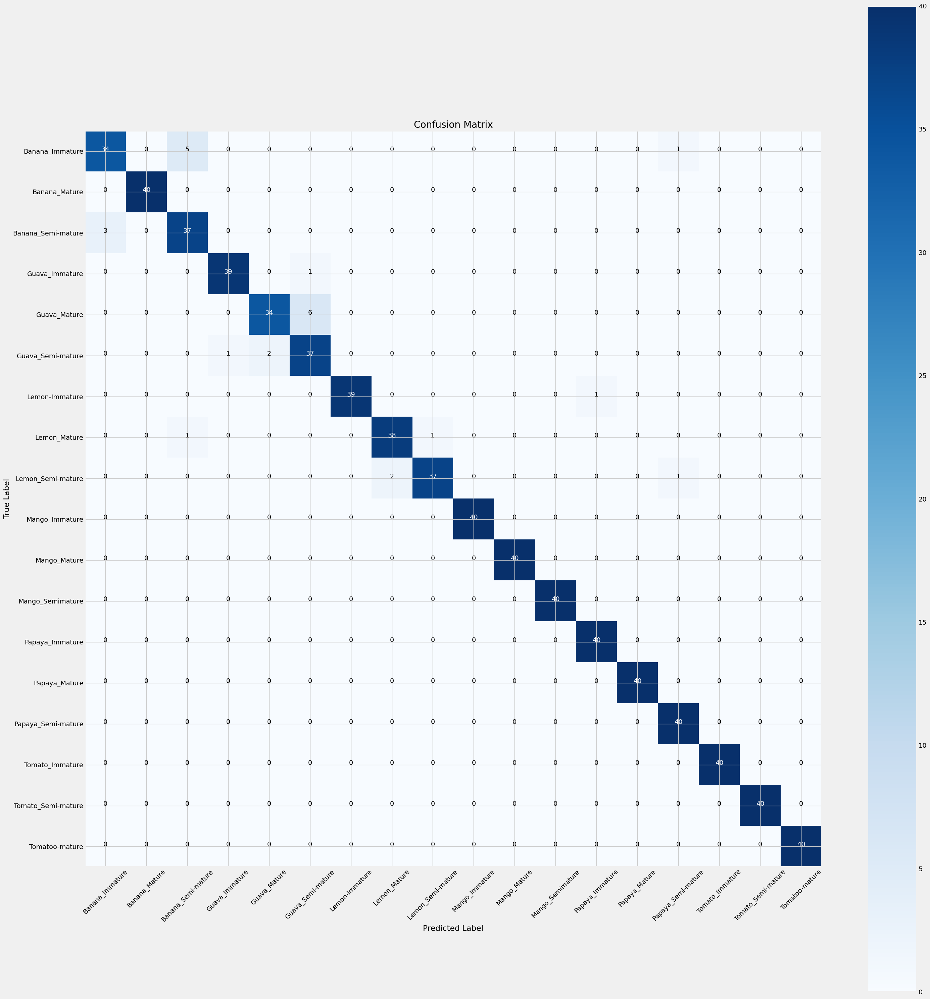

In [ ]:
preds = model.predict_generator(test_images)
y_pred = np.argmax(preds, axis=1)
g_dict = test_images.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_images.classes, y_pred)

plt.figure(figsize= (30, 30))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
y_true = test_images.classes
y_pred = np.argmax(model.predict(test_images), axis = 1)
f1 = f1_score(y_true, y_pred, average='macro')
print("F1 Score:", f1)
print(classification_report(y_true, y_pred, target_names=test_images.class_indices.keys()))

23/23 [==============================] - 3s 124ms/step
F1 Score: 0.9110577085342657
                    precision    recall  f1-score   support

   Banana_Immature       0.73      0.88      0.80        40
     Banana_Mature       0.97      0.97      0.97        40
Banana_Semi-mature       0.86      0.75      0.80        40
    Guava_Immature       1.00      0.72      0.84        40
      Guava_Mature       1.00      0.57      0.73        40
 Guava_Semi-mature       0.60      1.00      0.75        40
    Lemon-Immature       0.91      0.97      0.94        40
      Lemon_Mature       0.86      0.93      0.89        40
 Lemon_Semi-mature       0.97      0.72      0.83        40
    Mango_Immature       0.98      1.00      0.99        40
      Mango_Mature       1.00      1.00      1.00        40
  Mango_Semimature       0.97      0.97      0.97        40
   Papaya_Immature       0.97      0.95      0.96        40
     Papaya_Mature       1.00      0.97      0.99        40
Papaya_Semi-mat

In [ ]:
classes = dict(zip(test_images.class_indices.values(), test_images.class_indices.keys()))
Predictions = pd.DataFrame({"Image Index" : list(range(len(test_images.labels))),
                            "Test Labels" : test_images.labels,
                            "Test Classes" : [classes[i] for i in test_images.labels],
                            "Prediction Labels" : y_pred,
                            "Prediction Classes" : [classes[i] for i in y_pred],
                            "Path": test_images.filenames,
                            "Prediction Probability" : [x for x in np.asarray(tf.reduce_max(model.predict(test_images), axis = 1))]
                           })
Predictions.head(20)

23/23 [==============================] - 3s 116ms/step


,Image Index,Test Labels,Test Classes,Prediction Labels,Prediction Classes,Path,Prediction Probability
0,0,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.992637
1,1,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.999710
2,2,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.996754
3,3,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.969025
4,4,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.887487
5,5,0,Banana_Immature,2,Banana_Semi-mature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.557133
6,6,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.941919
7,7,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.992828
8,8,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.978867
9,9,0,Banana_Immature,0,Banana_Immature,/content/drive/MyDrive/Thesis/split/test/Banan...,0.928028


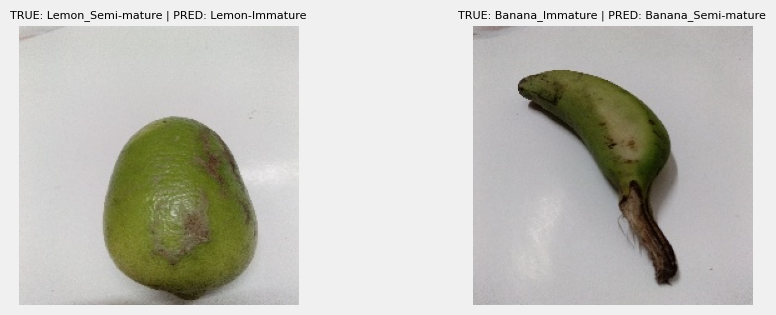

In [ ]:
plt.figure(figsize=(20,20))
for i, row in Predictions[Predictions["Test Labels"] != Predictions["Prediction Labels"]].sort_values("Prediction Probability").tail(20).reset_index().iterrows():
    plt.subplot(5,4,i+1)
    image_path = row['Path']
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(f'TRUE: {row["Test Classes"]} | PRED: {row["Prediction Classes"]}', fontsize=8)
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.models import load_model, save_model

model.save(BASE_DIR+'/Saved Models'+'/EfficientNetB5_Fined.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
